# preamble

## Auxilliary

In [2]:
import os
from exp import runNSave, get_times_file, record_eye, record_fun3

## Config

In [3]:
path = "."

# rule files
rules_files = [ os.path.join(path, f"rules_red{nr}.n3") for nr in range(1, 2) ]
# datasets
data_files = [ os.path.join(path, "data", f"gen{size}_pt{pt}.n3") for size in [ 100, 200, 500, 700, 1000, 2000, 5000 ] for pt in [ 1, 2, 5 ] ]
# data_files = [ os.path.join(path, "data", "gen100_pt1.n3") ]

# number of experiment runs
nr_runs = 1

# eye

Run the performance experiments using the eye reasoner.

In [ ]:
times_fh = get_times_file(os.path.join(path, "results"), 'eye')

query_file = os.path.join(path, "query_eye.n3")

for run in range(0, nr_runs):
    print("run:", run)
    
    for rules_file in rules_files:
        print("rules:", rules_file)
    
        for data_file in data_files:
            print("data:", data_file)
            
            rules_name = os.path.basename(rules_file)
            data_name = os.path.basename(data_file)
            
            eye_res_file = os.path.join(path, "results", "out", f"eye-{rules_name}-{data_name}.n3")
            
            netw_time, reas_time = runNSave(["eye", rules_file, data_file , "--query", query_file, "--nope"], eye_res_file)
            # load TURTLE format
            # netw_time, reas_time = runNSave(["eye", rules_file, "--turtle", data_file , "--query", query_file, "--nope"], eye_res_file)
            record_eye(times_fh, run, rules_name, data_name, netw_time, reas_time)

            times_fh.flush()
    
times_fh.close()

# fun3

Run the performance experiments using the fun3 reasoner.

In [ ]:
from pathlib import Path
import sys
sys.path.insert(0, "../../")
from n3.to_py import run_py, save_py

In [ ]:
# generate code files (for testing memoization impact on # calls)

# for memoize in True, False:
#     code_file = os.path.join(path, "results", "code", f"code_out_{"mem" if memoize else "nonmem"}.py")
#     query_file = os.path.join(path, "query.n3")
#     rules_file = "rules_red1.n3"
#     data_file = os.path.join(path, "data", "gen5000_pt2.n3")

#     params = { 'code_dir': "../../..", 'tracing': 'count_calls', 'gen': { 'call_query': True, 'memoize': memoize } }
#     save_py(Path(query_file), Path(rules_file), Path(data_file), code_file, params=params)

In [ ]:
memoize = False

times_fh = get_times_file(os.path.join(path, "results"), 'fun3')
query_file = os.path.join(path, "query.n3")

for run in range(0, nr_runs):
    print("run:", run)
    
    for rules_file in rules_files:
        print("rules:", rules_file)
    
        for data_file in data_files:
            print("data:", data_file)
            
            rules_name = os.path.basename(rules_file)
            data_name = os.path.basename(data_file)
            
            fun3_res_file = os.path.join(path, "results", "out", f"fun3-{rules_name}-{data_name}.n3")
            
            params = { 'gen': { 'memoize': memoize, 'experiment': True } }
            netw_time, gen_time, reas_time, total_time = run_py(Path(query_file), Path(rules_file), Path(data_file), save_to=fun3_res_file, params=params)
            record_fun3(times_fh, run, rules_name, data_name,netw_time, gen_time, reas_time, total_time)
    
        times_fh.flush()
    
times_fh.close()

# compare output

Compare the outputs generated by eye and fun3.

In [ ]:
import sys
sys.path.insert(0, "../../")

from n3.parse import parse_n3_file

for rules_file in rules_files:
    print("rules:", rules_file)

    for data_file in data_files:
        print("data:", data_file)
        
        rules_name = os.path.basename(rules_file)
        data_name = os.path.basename(data_file)
        
        eye_res_file = os.path.join(path, "results", "out", f"eye-{rules_name}-{data_name}.n3")
        fun3_res_file = os.path.join(path, "results", "out", f"fun3-{rules_name}-{data_name}.n3")

        model1 = parse_n3_file(eye_res_file).data; label1 = "eye"
        model2 = parse_n3_file(fun3_res_file).data; label2 = "fun3"

        compliant = True
        for t in model1.triples():
            if t not in model2.triples():
                print(f"different in {label1}:")
                print(t)
                compliant = False
                
        for t in model2.triples():
            if t not in model1.triples():
                print(f"different in {label2}:")
                print(t)
                compliant = False
                    
        if compliant:
            print("compliant")
        else:
            print("NON COMPLIANT")

# analyze

Analyze the performance of eye and fun3.

In [4]:
from exp import load_n3_times, load_n3_agg

In [12]:
import matplotlib.pyplot as plt

def plot_query(df_eye, df_fun3, data_label, query_id=None, col='total_time'):
    label = f"dataset {data_label}"
    if query_id is not None:
        label = f"ruleset {query_id+1} ({label})"
    plot(label, df_eye, df_fun3, col)

def plot(name, df_eye, df_fun3, col):
    fig, ax = plt.subplots()
    ax.set_title(name)

    df_eye.plot(x='data_id', y=col, ax=ax, label='eye', xlabel="dataset (# patients)", ylabel=f"{col} (ms)")
    df_fun3.plot(x='data_id', y=col, ax=ax, label='fun3', xlabel="dataset (# patients)", ylabel=f"{col} (ms)")

In [6]:
def avg_times(sys,df):
    print(sys)
    print("avg load time:", round(df['netw_time'].mean(), 0))
    print("avg reasoning time:", round(df['reas_time'].mean(), 0))
    if sys == 'fun3':
        print("avg code gen time:", round(df['gen_time'].mean(), 0))
    print("avg total time:", round(df['total_time'].mean(), 0))

## overall

In [21]:
df_eye = load_n3_times(os.path.join(path, "results", "times_eye.csv"))
# df_eye = load_n3_times(os.path.join(path, "results", "times_eye_turtle.csv"))
df_fun3 = load_n3_times(os.path.join(path, "results", "times_fun3.csv"))

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 2503.0
avg reasoning time: 39.0
avg total time: 2542.0
fun3
avg load time: 4569.0
avg reasoning time: 836.0
avg code gen time: 4.0
avg total time: 5409.0


## reasoning times

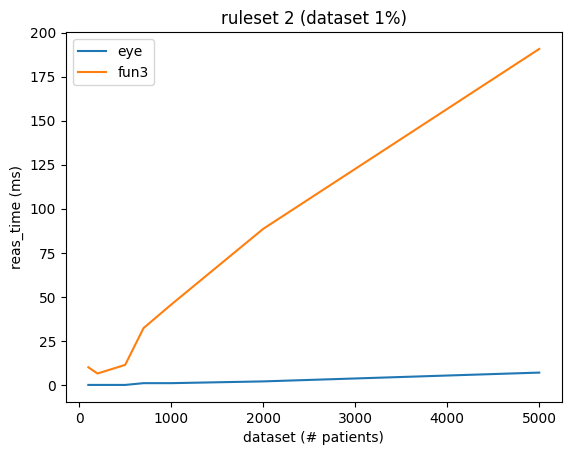

In [22]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt1", q="1")
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt1", q="1")
plot_query(df_eye, df_fun3, "1%", 1, col='reas_time')

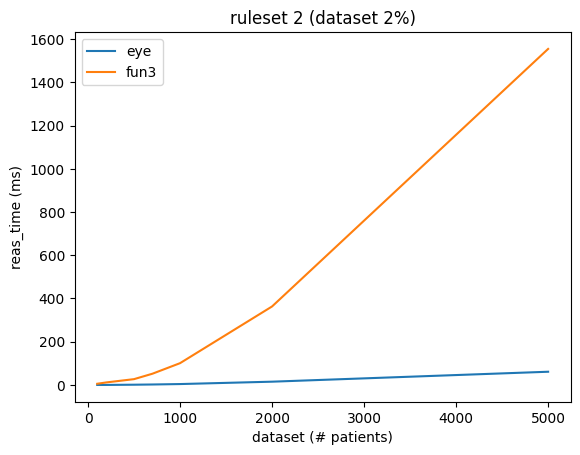

In [23]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt2", q="1")
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt2", q="1")
plot_query(df_eye, df_fun3, "2%", 1, col='reas_time')

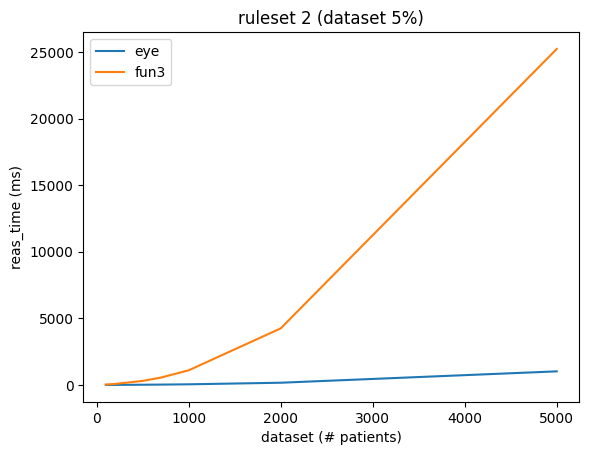

In [24]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt5", q="1")
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt5", q="1")
plot_query(df_eye, df_fun3, "5%", 1, col='reas_time')

## pt5

In [25]:
df_eye = load_n3_times(os.path.join(path, "results", "times_eye.csv"), pt="pt5")
df_fun3 = load_n3_times(os.path.join(path, "results", "times_fun3.csv"), pt="pt5")

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 4666.0
avg reasoning time: 104.0
avg total time: 4770.0
fun3
avg load time: 8105.0
avg reasoning time: 2292.0
avg code gen time: 4.0
avg total time: 10400.0


## pt1

In [26]:
df_eye = load_n3_times(os.path.join(path, "results", "times_eye.csv"), pt="pt1")
# df_eye = load_n3_times(os.path.join(path, "results", "times_eye_turtle.csv"), pt="pt1")
df_fun3 = load_n3_times(os.path.join(path, "results", "times_fun3.csv"), pt="pt1")

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 970.0
avg reasoning time: 3.0
avg total time: 973.0
fun3
avg load time: 1981.0
avg reasoning time: 44.0
avg code gen time: 4.0
avg total time: 2030.0


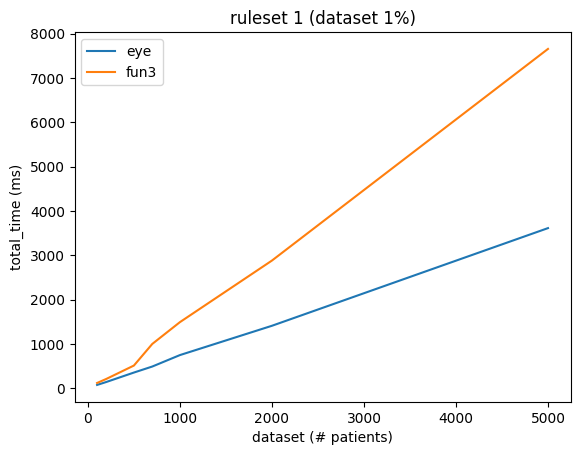

In [27]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt1", q="0")
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt1", q="0")

plot_query(df_eye, df_fun3, "1%", 0)

In [ ]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt1", q="1")
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt1", q="1")

plot_query(df_eye, df_fun3, "1%", 1)

## pt2

In [ ]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt2")
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt2")

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 1872.0
avg reasoning time: 11.0
avg total time: 1882.0
fun3
avg load time: 3623.0
avg reasoning time: 170.0
avg code gen time: 4.0
avg total time: 3797.0


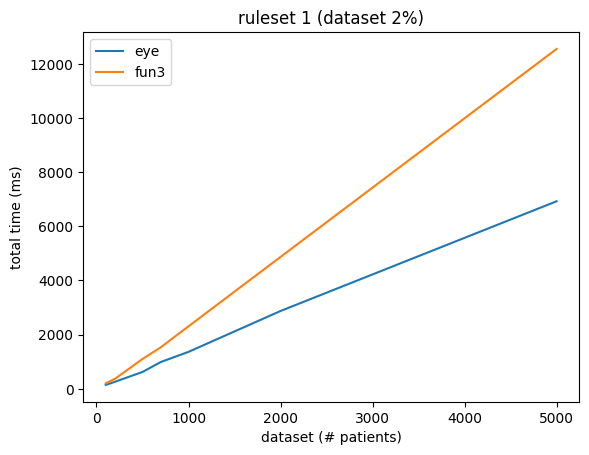

In [ ]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt2", q="0")
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt2", q="0")

plot_query(df_eye, df_fun3, "2%", 0)

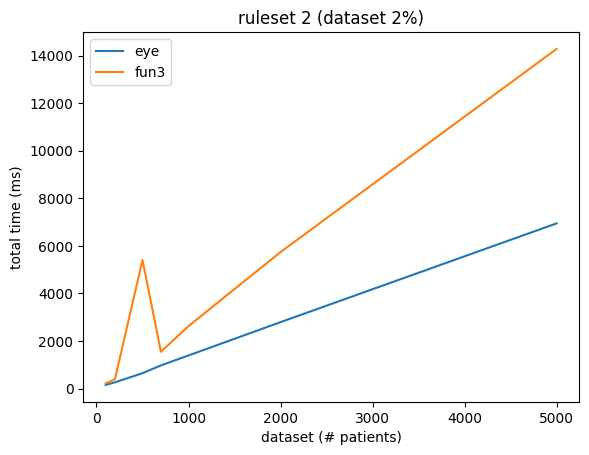

In [ ]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt2", q="1")
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt2", q="1")

plot_query(df_eye, df_fun3, "2%", 1)

## rule 0

In [ ]:
df_eye = load_n3_times(os.path.join(path, "results", "times_eye.csv"), q="0")
df_fun3 = load_n3_times(os.path.join(path, "results", "times_fun3.csv"), q="0")

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 2509.0
avg reasoning time: 12.0
avg total time: 2521.0
fun3
avg load time: 4455.0
avg reasoning time: 50.0
avg code gen time: 2.0
avg total time: 4508.0


## rule 1

In [ ]:
df_eye = load_n3_times(os.path.join(path, "results", "times_eye.csv"), q="1")
df_fun3 = load_n3_times(os.path.join(path, "results", "times_fun3.csv"), q="1")

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 2497.0
avg reasoning time: 66.0
avg total time: 2562.0
fun3
avg load time: 4684.0
avg reasoning time: 1621.0
avg code gen time: 5.0
avg total time: 6310.0


# sanity check

## consistency across runs

### eye

In [ ]:
df_n3 = load_n3_times(os.path.join(path, "results", "times_eye.csv"))
cols = ['netw_time', 'reas_time', 'total_time']
df_n3_agg = df_n3.groupby(['run'])[cols].mean().reset_index()

df_n3_agg = df_n3_agg.sort_values(by='run')
df_n3_agg

# eye
# avg load time: 521.0
# avg reasoning time: 2.0
# avg total time: 523.0

,run,netw_time,reas_time,total_time
0,0,2502.666667,39.071429,2541.738095


### fun3

In [ ]:
df_n3 = load_n3_times(os.path.join(path, "results", "times_fun3.csv"))
cols = ['netw_time', 'reas_time', 'total_time', 'gen_time']
df_n3_agg = df_n3.groupby(['run'])[cols].mean().reset_index()

df_n3_agg = df_n3_agg.sort_values(by='run')
df_n3_agg

# fun3
# avg load time: 23.0
# avg reasoning time: 952.0
# avg code gen time: 6.0
# avg total time: 975.0

,run,netw_time,reas_time,total_time,gen_time
0,0,4569.417927,835.582073,5409.02381,3.785714
